# Testing SNEC dev
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [37]:
import numpy as np
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import SNEC_output_parser, plot_vel_radius_at_time_t, plot_mass_radius, plot_v_radius_time
import astropy.units as u
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
root = "/home/mrenzo/Documents/Research/codes/SNEC-1.01/Data/"
baseline = root+"baseline/"
final_E_zero = root+"final_E_zero/"
testing = root+"testing/"

In [23]:
baseline_vel = baseline+"vel.xg"
baseline_mass = baseline+"mass.xg"

final_E_zero_vel = final_E_zero+"vel.xg"
final_E_zero_mass = final_E_zero+"mass.xg"

testing_vel = testing+"vel.xg"
testing_mass = testing+"mass.xg"

# get times from testing model
vel_data = SNEC_output_parser(testing_vel)
keys = np.array(list(vel_data.keys()))
vel_times = keys * u.s

# define colors
colors = plt.cm.viridis(np.linspace(0,1, len(vel_times)))


Text(0, 0.5, '$m \\ [M_{\\odot}]$')

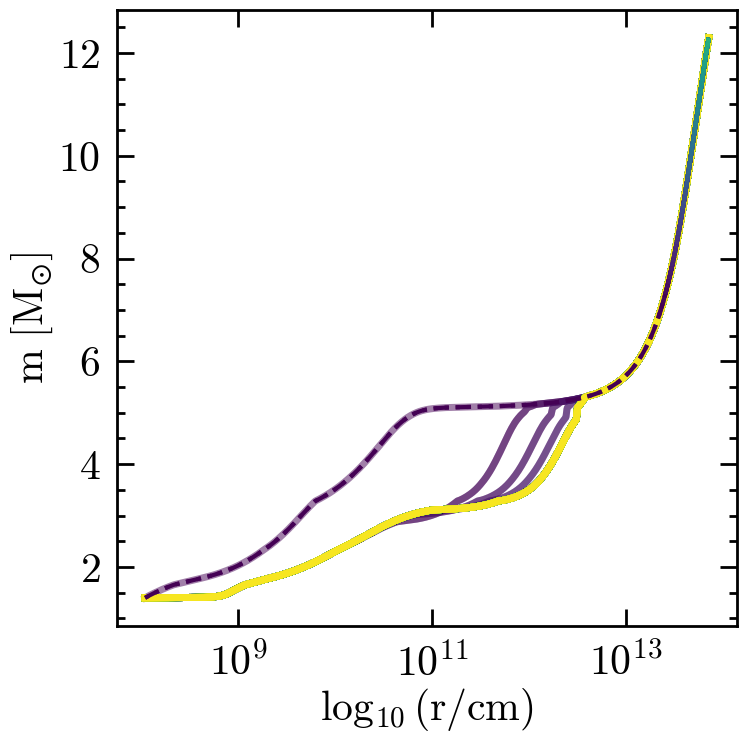

In [28]:
# mass vs time
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for i, t in enumerate(vel_times):
    # if i%2 == 0: continue
    plot_mass_radius(t, baseline_mass, ls='-', c=colors[i], ax=ax, lw=5, alpha=0.5, zorder=0)
    plot_mass_radius(t, final_E_zero_mass, ls='--', c=colors[i], ax=ax, zorder=1)
    plot_mass_radius(t, testing_mass, ls=':', c=colors[i], ax=ax, zorder=2)

ax.set_xscale("log")
ax.set_xlabel(r"$\log_{10}(r/\mathrm{cm})$")
ax.set_ylabel(r"$m \ [M_{\odot}]$")

Text(0, 0.5, '$v \\ [\\mathrm{km\\ s^{-1}}]$')

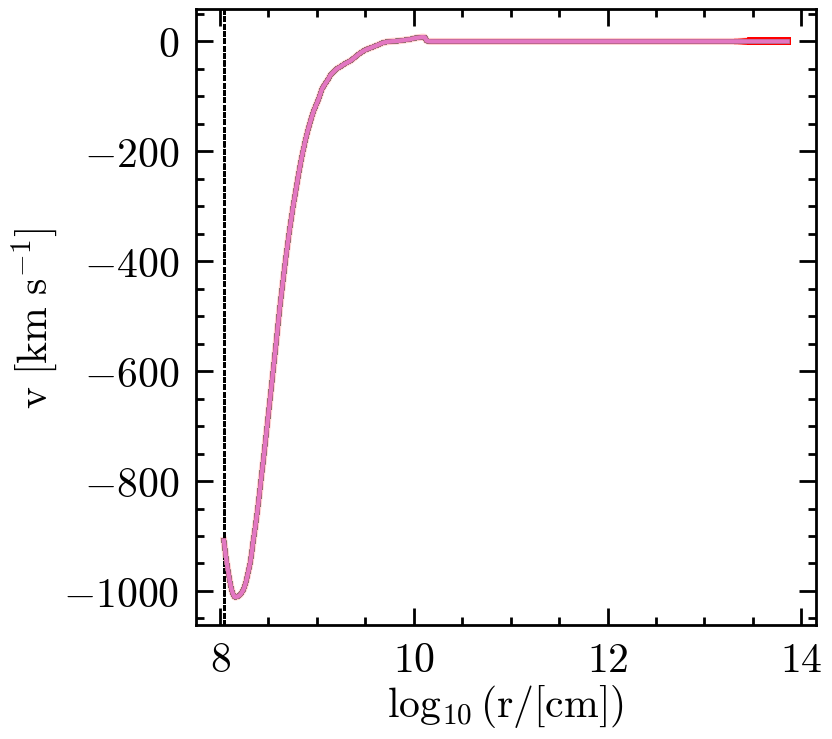

In [36]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for i, t in enumerate(vel_times):
    # if i%2 ==0: continue
    alpha = max(min(1.0-(0.8 - 0.01*i), 1.0), 0.0)
    # plot_v_radius_time(t, baseline_vel, baseline_mass, ax=ax, # label=f"{t.to(u.h):.1f}",
    #                    c='b', alpha=alpha)
    # plot_v_radius_time(t, final_E_zero_weak_expl_vel, final_E_zero_weak_expl_mass, ax=ax, label=f"{t.to(u.h):.1f}", c='r', alpha=alpha)
    plot_v_radius_time(t, final_E_zero_vel, final_E_zero_mass, ax=ax, label=f"{t.to(u.h):.1f}",
                       alpha=alpha, c='r', lw=5, zorder=0)
    plot_v_radius_time(t, testing_vel, testing_mass, ax=ax, label=f"{t.to(u.h):.1f}", zorder=1
                       # alpha=alpha, c='r'
                       )

ax.set_xlabel(r'$\log_{10}(r/\mathrm{[cm]})$')
ax.set_ylabel(r'$v \ [\mathrm{km\ s^{-1}}]$')
# ax.legend(ncol=3, fontsize=20)
# ax.set_ylim(-10, 10)

In [12]:
# Mass vs time
mass_data = SNEC_output_parser(final_E_zero_mass)
keys = np.array(list(mass_data.keys()))
mass_times = keys * u.s
try:
    units = mass_times.unit
except AttributeError:
    mass_times *= u.s

for i, t in enumerate(mass_times):
    mass = mass_data[keys[i]][:, 1] * u.g
    print(t, min(mass).to(u.Msun), max(mass).to(u.Msun))

0.0 s 1.400359171935954 solMass 12.292135711144635 solMass
935.8468289746102 s 1.400359171935954 solMass 12.292135711144635 solMass
1867.1456680053902 s 1.400359171935954 solMass 12.292135711144635 solMass
2771.171790697481 s 1.400359171935954 solMass 12.292135711144635 solMass
3726.479161104709 s 1.400359171935954 solMass 12.292135711144635 solMass
4612.912643076779 s 1.400359171935954 solMass 12.292135711144635 solMass
5512.912643076779 s 1.400359171935954 solMass 12.292135711144635 solMass
6412.912643076779 s 1.400359171935954 solMass 12.292135711144635 solMass
7312.912643076779 s 1.400359171935954 solMass 12.292135711144635 solMass
8212.91264307678 s 1.400359171935954 solMass 12.292135711144635 solMass
8640.0 s 1.400359171935954 solMass 12.292135711144635 solMass


/tmp/ipykernel_1209025/3239678368.py:14: RuntimeWarning: divide by zero encountered in log10
  ax.plot(mass.to(u.Msun), np.log10(rho.value), **kwargs)


Text(0.5, 0, '$m \\ [M_{\\odot}]$')

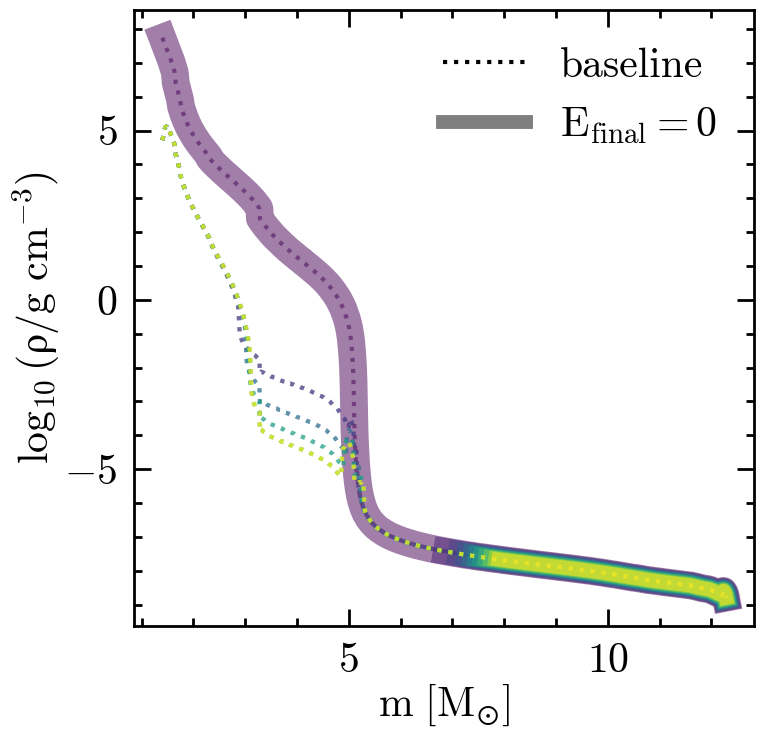

In [18]:
# density profiles?
def plot_rho_pfile(t, rho_out, ax=None, **kwargs):
    data = SNEC_output_parser(rho_out)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    index_time_of_interest = np.argmin(np.absolute(times-t))
    key_of_interest = keys[index_time_of_interest]
    rho = data[key_of_interest][:, 1] * u.g/u.cm**3
    mass = data[key_of_interest][:, 0] * u.g
    ax.plot(mass.to(u.Msun), np.log10(rho.value), **kwargs)



fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

baseline_rho = baseline+"rho.xg"
final_E_zero_rho = final_E_zero+"rho.xg"

colors = plt.cm.viridis(np.linspace(0,1, len(vel_times)))


for i, t in enumerate(vel_times):
    # print(i)
    plot_rho_pfile(t, final_E_zero_rho, ax=ax, # label=f'{t}',
                   c=colors[i], lw=20-i, alpha=0.5)
    plot_rho_pfile(t, baseline_rho, ax=ax, ls=':', alpha=0.5, c=colors[i])


ax.plot(np.nan, np.nan, ls=":", c='k', label="baseline")
ax.plot(np.nan, np.nan, lw=10, c='k', alpha=0.5, label=r"$E_{\rm final}=0$")
ax.legend()
ax.set_ylabel(r"$\log_{10}(\rho/\mathrm{g\ cm^{-3}})$")
ax.set_xlabel(r"$m \ [M_{\odot}]$")

/tmp/ipykernel_1209025/3821971008.py:16: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.log10(radius.to(u.cm).value), np.log10(rho.value), **kwargs)
/tmp/ipykernel_1209025/3821971008.py:16: RuntimeWarning: invalid value encountered in log10
  ax.plot(np.log10(radius.to(u.cm).value), np.log10(rho.value), **kwargs)


Text(0.5, 0, '$\\log_{10}(r/\\mathrm{cm})$')

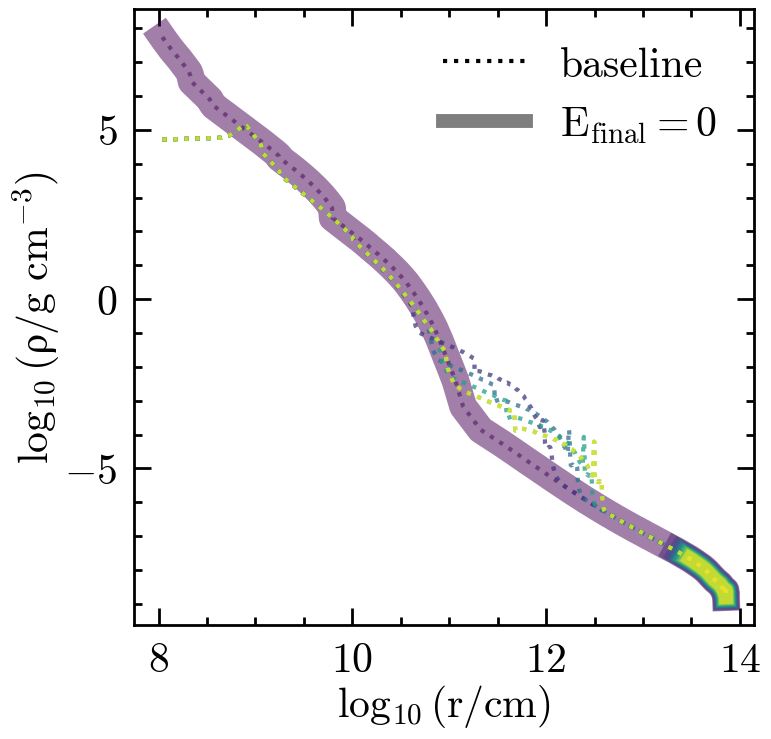

In [22]:
# Density vs. Radius
def plot_rho_r_pfile(t, rho_out, mass_out, ax=None, **kwargs):
    data = SNEC_output_parser(rho_out)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    index_time_of_interest = np.argmin(np.absolute(times-t))
    key_of_interest = keys[index_time_of_interest]
    rho = data[key_of_interest][:, 1] * u.g/u.cm**3
    mass = data[key_of_interest][:, 0] * u.g
    mass_data = SNEC_output_parser(mass_out)
    radius = mass_data[key_of_interest][:, 0] * u.cm
    ax.plot(np.log10(radius.to(u.cm).value), np.log10(rho.value), **kwargs)



fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

baseline_rho = baseline+"rho.xg"
final_E_zero_rho = final_E_zero+"rho.xg"
baseline_mass = baseline+"mass.xg"
final_E_zero_mass = final_E_zero+"mass.xg"

colors = plt.cm.viridis(np.linspace(0,1, len(vel_times)))

for i, t in enumerate(vel_times):
    # print(i)
    plot_rho_r_pfile(t, final_E_zero_rho, final_E_zero_mass, ax=ax, # label=f'{t}',
                     c=colors[i], lw=20-i, alpha=0.5)
    plot_rho_r_pfile(t, baseline_rho, baseline_mass,  ax=ax, ls=':', alpha=0.5, c=colors[i])
ax.plot(np.nan, np.nan, ls=":", c='k', label="baseline")
ax.plot(np.nan, np.nan, lw=10, c='k', alpha=0.5, label=r"$E_{\rm final}=0$")
ax.legend()
ax.set_ylabel(r"$\log_{10}(\rho/\mathrm{g\ cm^{-3}})$")
ax.set_xlabel(r"$\log_{10}(r/\mathrm{cm})$")


In [ ]:
# where is the shock?


